# LoanLens — Exploratory Data Analysis (EDA)

**Project:** Explainable AI Credit Decision Simulator  
**Course:** AI for Engineers

> **EDA means understanding the data before asking a machine-learning model to learn from it.**

In this notebook we will inspect the dataset's structure, quality, distributions, target relationships, and potential modelling risks.

We intentionally **do not train a final model in this notebook**. The findings here will determine our preprocessing and modelling strategy.


## 1. Imports and setup

We use:
- **Pandas** for tabular data analysis.
- **NumPy** for numerical operations.
- **Matplotlib** and **Seaborn** for visualization.
- **Path** so the dataset path works reliably from the repository.


In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid")


Matplotlib is building the font cache; this may take a moment.


## 2. Load the dataset

The original CSV should remain unchanged in `data/raw/`.

Because this notebook lives inside `notebooks/`, the code below first checks whether the current working directory is the notebook folder and, if necessary, moves one level up to the repository root.


In [18]:
project_root = Path.cwd().resolve()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_path = project_root / "data" / "raw" / "loan_approval.csv"

if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {data_path}\n"
        "Make sure loan_approval.csv is inside data/raw/."
    )

df = pd.read_csv(data_path)

print(f"Loaded: {data_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Loaded: D:\PROJECTS\loanlens\data\raw\loan_approval.csv
Shape: 3,192 rows × 14 columns


## 3. First look at the data

`shape` tells us how large the dataset is, while `head()` lets us inspect a few actual records.

This is our first sanity check: we want to make sure the CSV was parsed correctly and the columns look as expected.


In [19]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

df.head()


Dataset shape: (3192, 14)

Column names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Employment_Status', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Term', 'Credit_History', 'Property_Area', 'Age', 'Loan_Status']


,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
0,LN03437,Female,Yes,3,Graduate,Salaried,"34,473.91","13,914.72","240,732.46",180,1,Semiurban,40.08,Approved
1,LN04823,Female,Yes,1,Graduate,Self-Employed,"59,718.02","18,720.81","122,547.28",180,1,Semiurban,47.24,Approved
2,LN04186,Female,Yes,1,Not Graduate,Salaried,"106,981.52","2,229.15","140,550.94",60,1,Rural,24.29,Approved
3,LN00380,Male,Yes,2,Graduate,Salaried,"43,205.56","35,578.11","146,135.74",120,1,Semiurban,38.74,Approved
4,LN04698,Female,Yes,0,Graduate,Salaried,"62,526.28","20,212.16","203,408.05",180,1,Semiurban,41.16,Approved


## 4. Data types and feature groups

A feature's **data type is not the same thing as its semantic meaning**.

For example, `Credit_History` may contain `0` and `1`, but it represents a binary credit-history category rather than a continuous measurement.

We therefore inspect the raw types first and will later define feature groups based on both type **and meaning**.


In [20]:
df.info()

print("\nNumerical columns detected by Pandas:")
print(df.select_dtypes(include="number").columns.tolist())

print("\nCategorical/text columns detected by Pandas:")
print(df.select_dtypes(exclude="number").columns.tolist())


<class 'pandas.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             3192 non-null   str    
 1   Gender              3115 non-null   str    
 2   Married             3126 non-null   str    
 3   Dependents          3192 non-null   int64  
 4   Education           3126 non-null   str    
 5   Employment_Status   3136 non-null   str    
 6   Applicant_Income    3157 non-null   float64
 7   Coapplicant_Income  3192 non-null   float64
 8   Loan_Amount         3151 non-null   float64
 9   Loan_Term           3192 non-null   int64  
 10  Credit_History      3192 non-null   int64  
 11  Property_Area       3192 non-null   str    
 12  Age                 3192 non-null   float64
 13  Loan_Status         3192 non-null   str    
dtypes: float64(4), int64(3), str(7)
memory usage: 349.3 KB

Numerical columns detected by Pandas:
['Dependents', 'Appli

## 5. Missing-value analysis

A missing value means the dataset does not contain an observation for that field.

We inspect both the **count** and **percentage** of missing values. We will not fill them here because imputation belongs inside the later train/test-safe preprocessing pipeline.


In [21]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
})

missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_count", ascending=False)
)

if missing_summary.empty:
    print("No missing values found.")
else:
    display(missing_summary)


,missing_count,missing_percent
Gender,77,2.41
Married,66,2.07
Education,66,2.07
Employment_Status,56,1.75
Loan_Amount,41,1.28
Applicant_Income,35,1.10


## 6. Duplicate and identifier checks

Duplicate applications can distort analysis and model evaluation.

`Loan_ID` is an identifier. We keep it for traceability, but an identifier normally should **not** be used as a predictive feature because the model could learn meaningless ID patterns.


In [22]:
duplicate_rows = df.duplicated().sum()
unique_ids = df["Loan_ID"].nunique(dropna=True)
missing_ids = df["Loan_ID"].isna().sum()

print(f"Exact duplicate rows: {duplicate_rows:,}")
print(f"Unique Loan_ID values: {unique_ids:,} of {len(df):,} rows")
print(f"Missing Loan_ID values: {missing_ids:,}")


Exact duplicate rows: 0
Unique Loan_ID values: 3,192 of 3,192 rows
Missing Loan_ID values: 0


## 7. Target sanity check

Our target is `Loan_Status`.

Before modelling, we need to know whether the target classes are balanced. Severe class imbalance can make accuracy misleading.

Here we calculate both counts and percentages.


In [23]:
target_summary = (
    df["Loan_Status"]
    .value_counts(dropna=False)
    .rename_axis("Loan_Status")
    .reset_index(name="count")
)

target_summary["percentage"] = (
    target_summary["count"] / len(df) * 100
).round(2)

display(target_summary)


,Loan_Status,count,percentage
0,Approved,1596,50.00
1,Rejected,1596,50.00


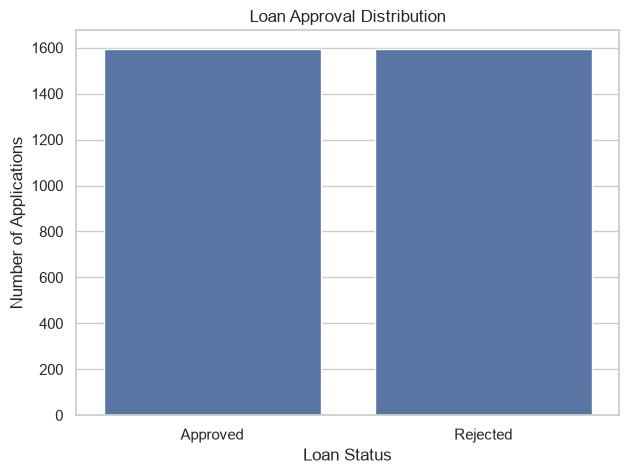

In [24]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Loan_Status")

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()


### Interpretation

If the two bars are approximately equal, the target is balanced.

A balanced target means we do not need to rely on accuracy alone because of a severe class imbalance. We will still report precision, recall, F1-score, ROC-AUC, and a confusion matrix during modelling.


## 8. Numerical-feature overview

We first inspect the descriptive statistics of the main continuous/quantity variables.

For this dataset, we treat the following as numerical measurements:

- `Applicant_Income`
- `Coapplicant_Income`
- `Loan_Amount`
- `Loan_Term`
- `Age`

`Dependents` and `Credit_History` are intentionally excluded here because their numeric representation has categorical/ordinal meaning.


In [25]:
numerical_features = [
    "Applicant_Income",
    "Coapplicant_Income",
    "Loan_Amount",
    "Loan_Term",
    "Age",
]

numeric_summary = df[numerical_features].describe().T
numeric_summary["missing_count"] = df[numerical_features].isna().sum()

display(numeric_summary.round(2))


,count,mean,std,min,25%,50%,75%,max,missing_count
Applicant_Income,"3,157.00","59,962.64","19,932.96","15,000.00","46,485.84","60,290.18","73,118.02","138,524.75",35
Coapplicant_Income,"3,192.00","15,091.34","9,541.48",0.00,"7,915.10","14,608.47","21,758.38","47,877.61",0
Loan_Amount,"3,151.00","151,459.71","50,313.61","20,000.00","116,986.77","151,967.79","186,201.80","373,954.21",41
Loan_Term,"3,192.00",212.37,101.43,60.00,120.00,240.00,300.00,360.00,0
Age,"3,192.00",35.20,7.72,21.00,29.85,35.05,40.54,61.16,0


## 9. Numerical distributions

A histogram shows how observations are distributed across a numerical variable.

We look for:
- the typical range
- concentration of observations
- skewness
- unusual gaps
- possible extreme values

We are **not automatically removing or transforming outliers**. First we need to understand them.


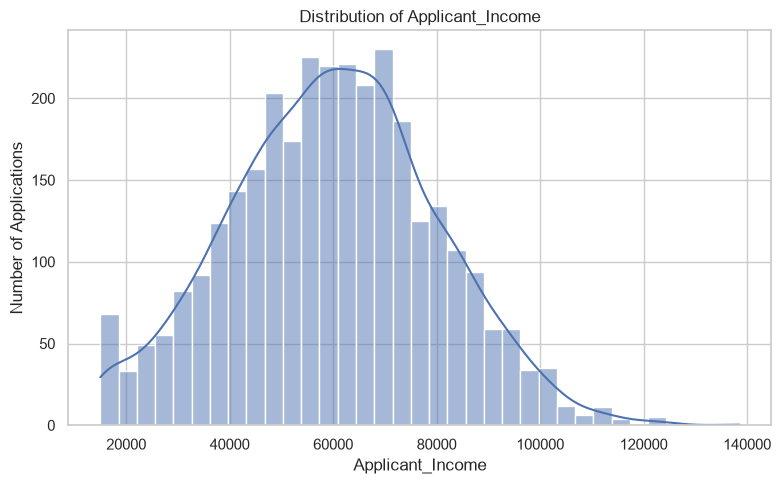

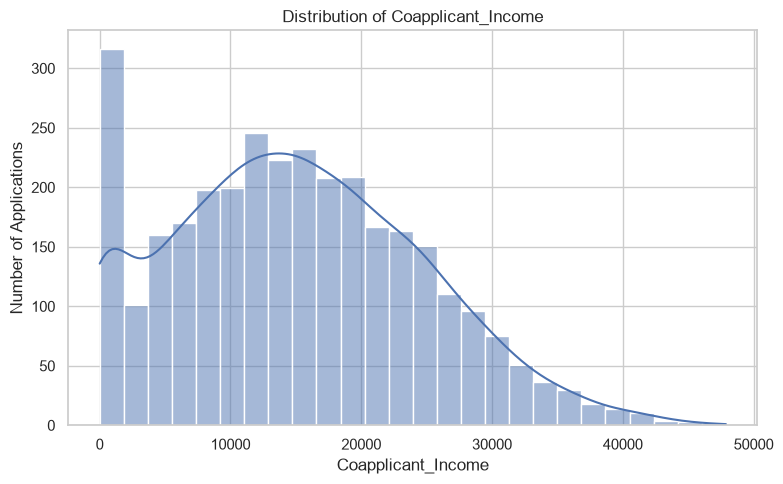

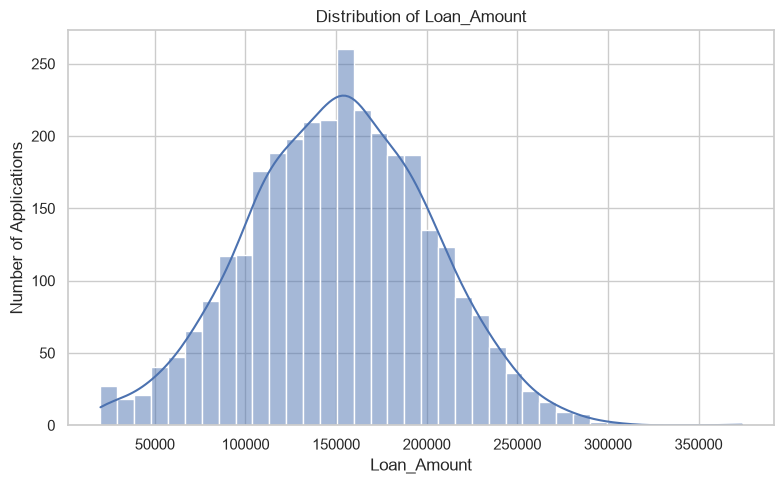

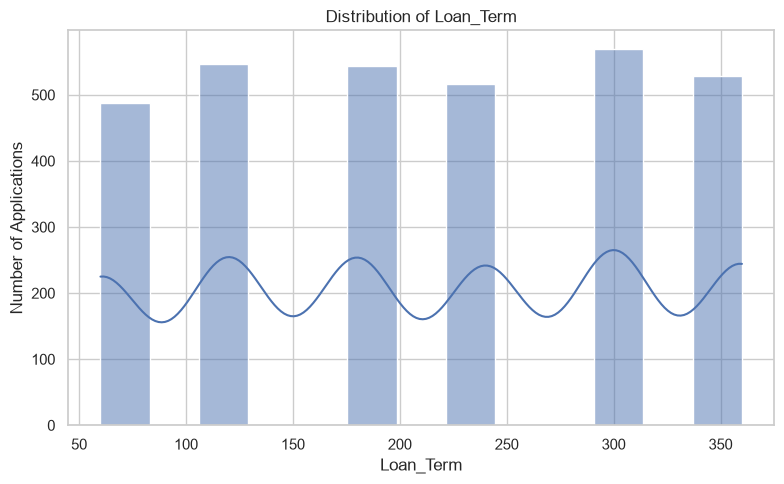

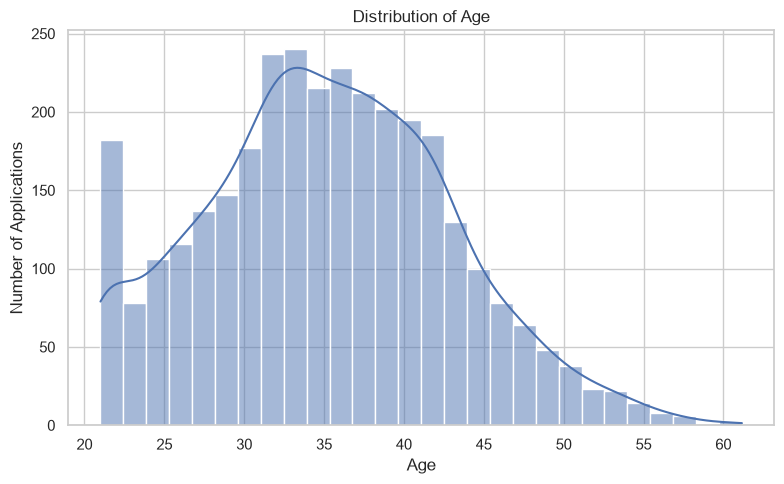

In [26]:
for feature in numerical_features:
    plt.figure(figsize=(8, 5))

    sns.histplot(data=df, x=feature, kde=True)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Applications")

    plt.tight_layout()
    plt.show()


## 10. Numerical features and potential outliers

A boxplot provides a compact view of the median, middle 50% of observations, and potential extreme observations.

A point outside the whiskers is a **potential outlier**, not automatically a bad record. In financial data, unusually high incomes or loan amounts can be legitimate.


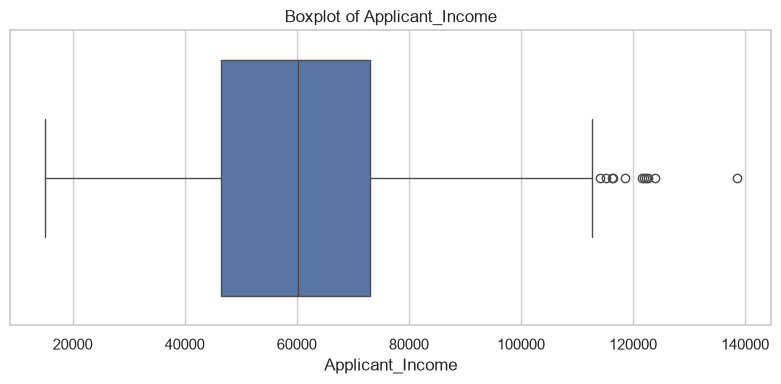

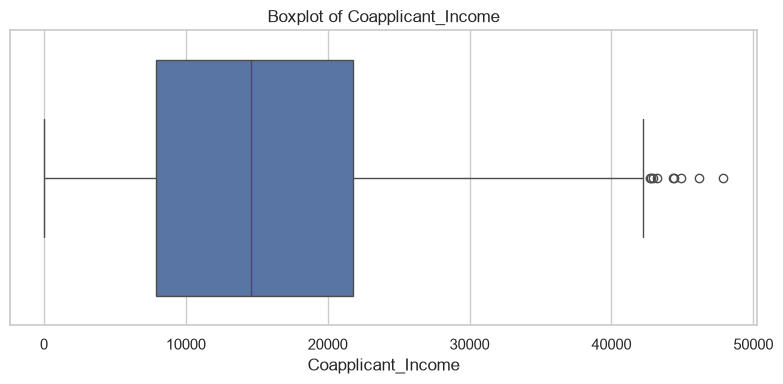

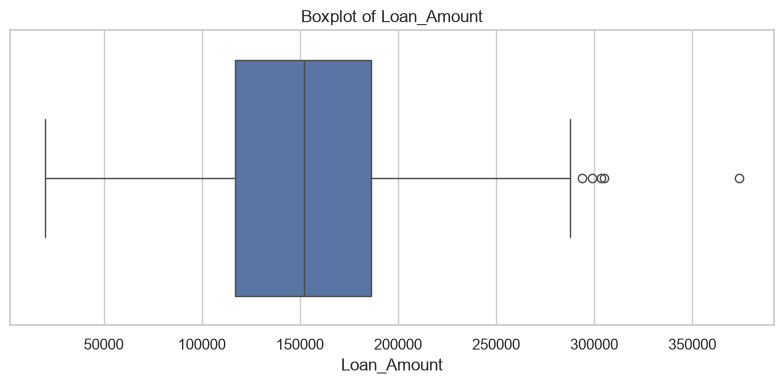

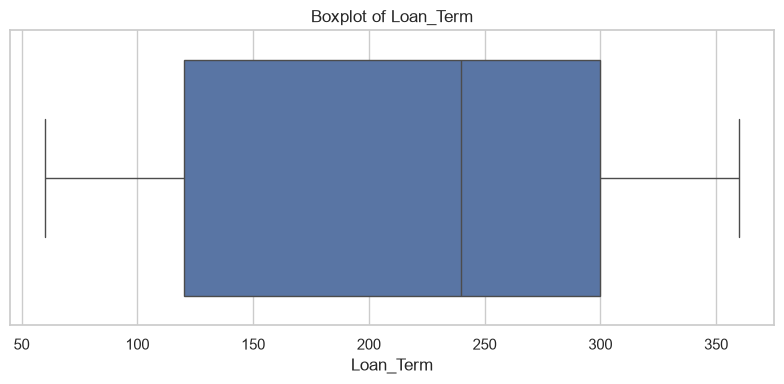

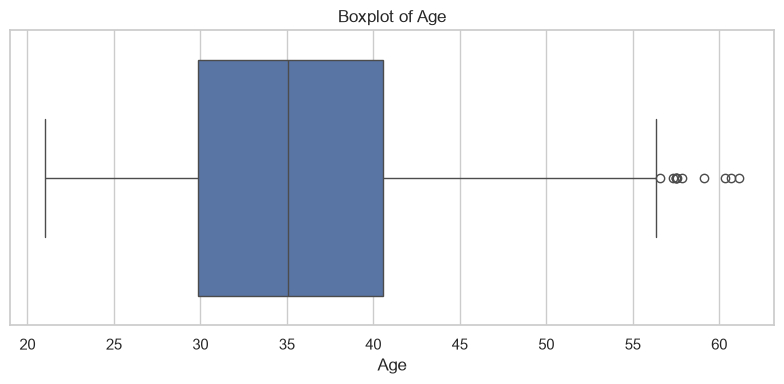

In [27]:
for feature in numerical_features:
    plt.figure(figsize=(8, 4))

    sns.boxplot(data=df, x=feature)

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()


## 11. Categorical feature distributions

For categorical features, frequency counts are more informative than numerical summary statistics.

We inspect:
- `Gender`
- `Married`
- `Education`
- `Employment_Status`
- `Property_Area`
- `Dependents`
- `Credit_History`


In [28]:
categorical_features = [
    "Gender",
    "Married",
    "Education",
    "Employment_Status",
    "Property_Area",
    "Dependents",
    "Credit_History",
]

for feature in categorical_features:
    print(f"\n--- {feature} ---")
    print(df[feature].value_counts(dropna=False).to_string())



--- Gender ---
Gender
Male      1995
Female    1120
NaN         77

--- Married ---
Married
Yes    2205
No      921
NaN      66

--- Education ---
Education
Graduate        2323
Not Graduate     803
NaN               66

--- Employment_Status ---
Employment_Status
Salaried         2178
Self-Employed     809
Unemployed        149
NaN                56

--- Property_Area ---
Property_Area
Urban        1579
Semiurban     987
Rural         626

--- Dependents ---
Dependents
0    1229
1     993
2     673
3     297

--- Credit_History ---
Credit_History
1    1650
0    1542


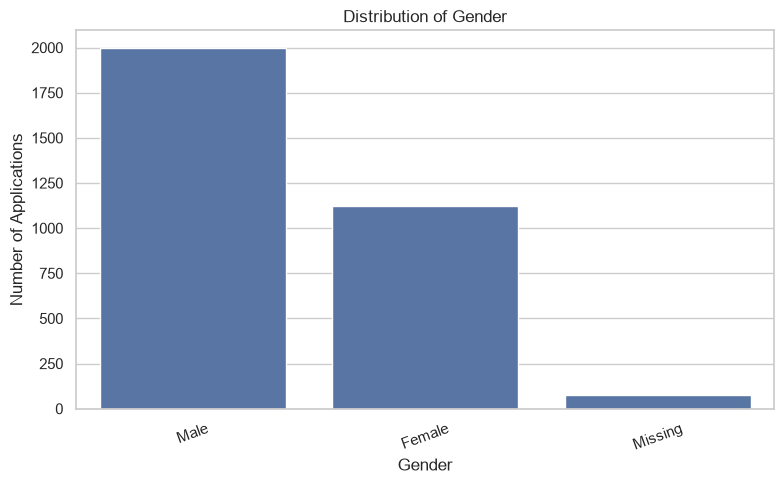

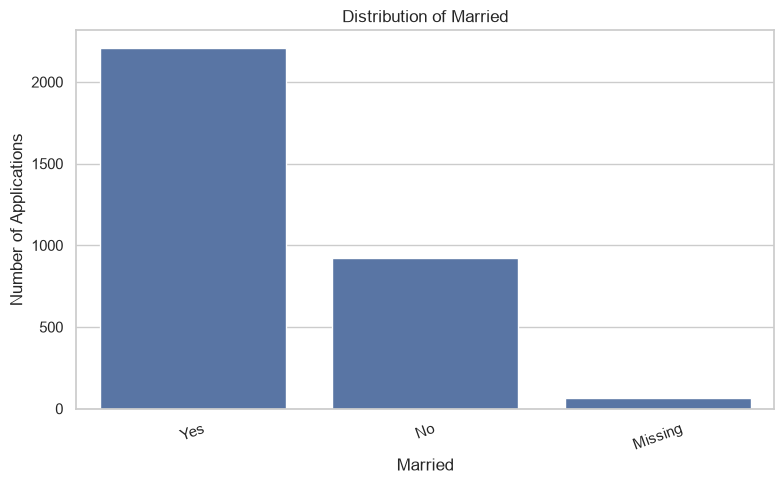

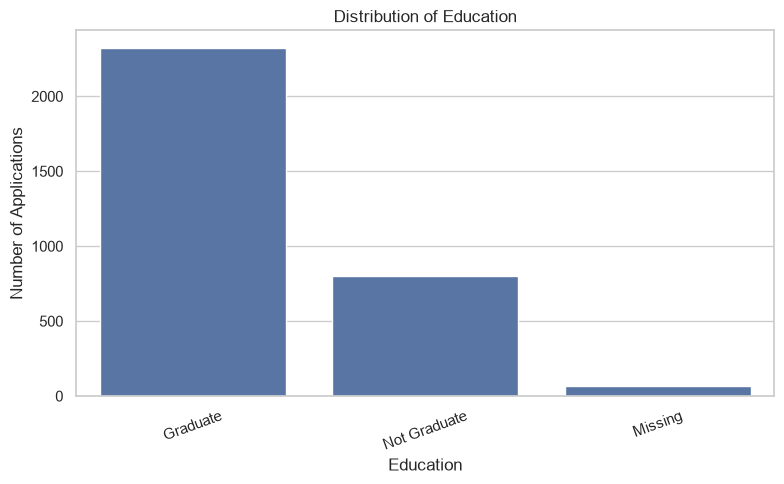

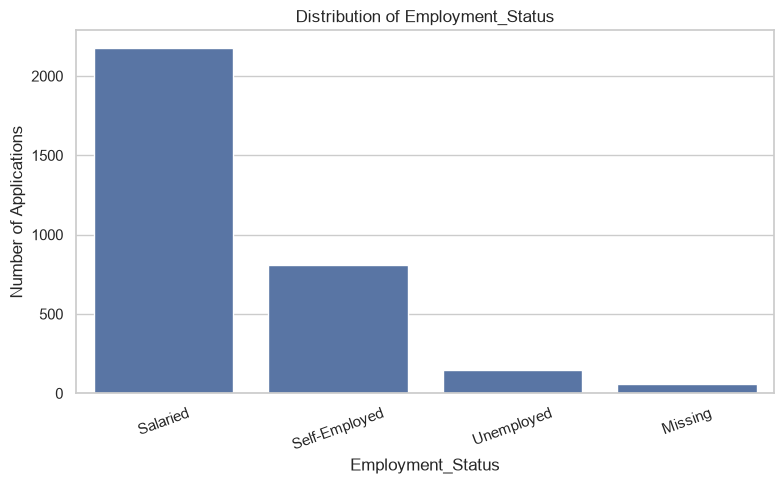

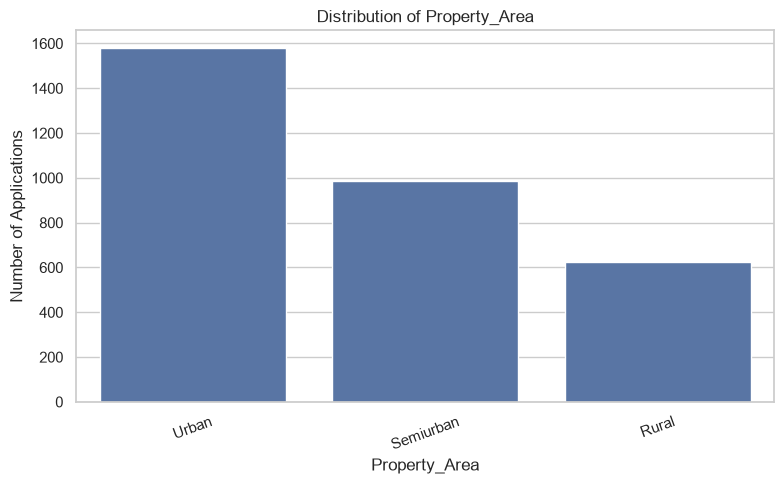

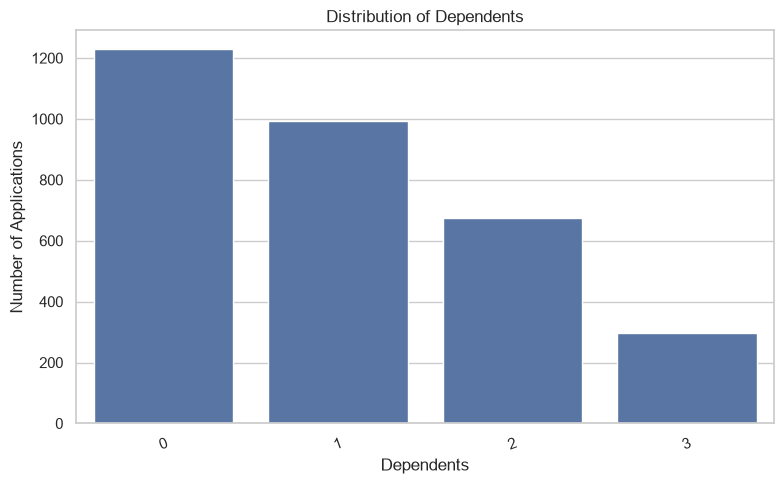

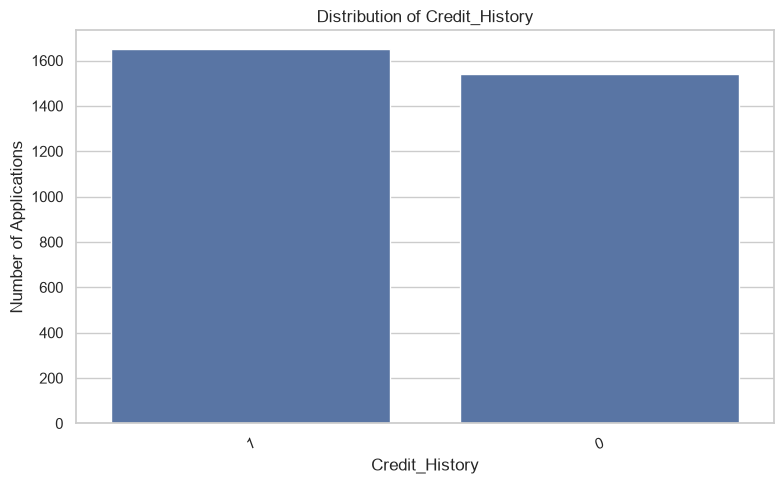

In [30]:
for feature in categorical_features:
    plot_data = df[feature].astype("object").where(
        df[feature].notna(),
        "Missing"
    )

    order = plot_data.value_counts().index

    plt.figure(figsize=(8, 5))

    sns.countplot(
        x=plot_data,
        order=order
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Applications")
    plt.xticks(rotation=20)

    plt.tight_layout()
    plt.show()

## 12. Approval rate by feature

A useful way to investigate a classification problem is to calculate the percentage of applications that were approved **within each category**.

For example:

> Of applicants with `Credit_History = 1`, what percentage were approved?

This measures **association**, not causation.


In [31]:
def approval_rate_by(feature: str) -> pd.DataFrame:
    result = pd.crosstab(
        df[feature],
        df["Loan_Status"],
        dropna=False
    )

    result["Total"] = result.sum(axis=1)

    approved_count = result["Approved"] if "Approved" in result.columns else 0
    result["Approval_rate_percent"] = (
        approved_count / result["Total"] * 100
    ).round(2)

    return result.sort_values(
        "Approval_rate_percent",
        ascending=False
    )


In [32]:
for feature in [
    "Gender",
    "Married",
    "Education",
    "Employment_Status",
    "Property_Area",
    "Dependents",
    "Credit_History",
]:
    print(f"\n### Approval rate by {feature}")
    display(approval_rate_by(feature))



### Approval rate by Gender


Loan_Status,Approved,Rejected,Total,Approval_rate_percent
Gender,,,,
NaN,41,36,77,53.25
Female,564,556,1120,50.36
Male,991,1004,1995,49.67



### Approval rate by Married


Loan_Status,Approved,Rejected,Total,Approval_rate_percent
Married,,,,
Yes,1108,1097,2205,50.25
No,457,464,921,49.62
NaN,31,35,66,46.97



### Approval rate by Education


...

Loan_Status,Approved,Rejected,Total,Approval_rate_percent
Property_Area,,,,
Urban,810,769,1579,51.30
Semiurban,483,504,987,48.94
Rural,303,323,626,48.40



### Approval rate by Dependents


Loan_Status,Approved,Rejected,Total,Approval_rate_percent
Dependents,,,,
3,157,140,297,52.86
2,345,328,673,51.26
1,492,501,993,49.55
0,602,627,1229,48.98



### Approval rate by Credit_History


Loan_Status,Approved,Rejected,Total,Approval_rate_percent
Credit_History,,,,
1,1595,55,1650,96.67
0,1,1541,1542,0.06


## 13. Visual comparison of approval rates

The following plots make differences between groups easier to see.

A feature with similar approval rates across categories has weaker evidence of association with the target. A feature with dramatically different rates deserves further investigation.


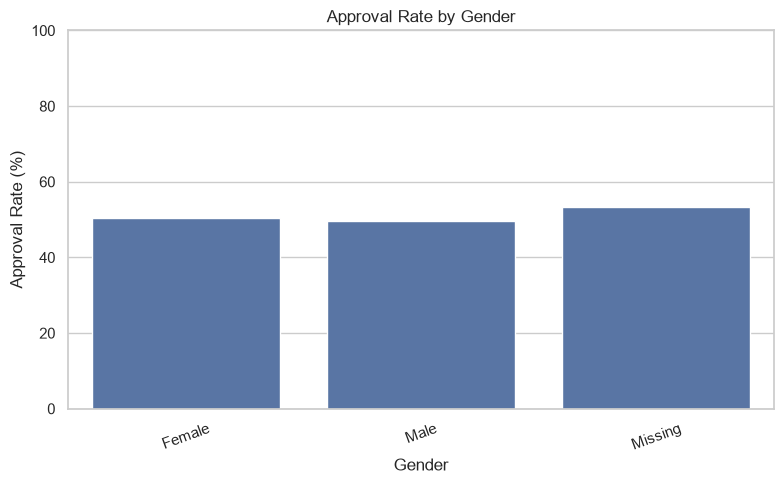

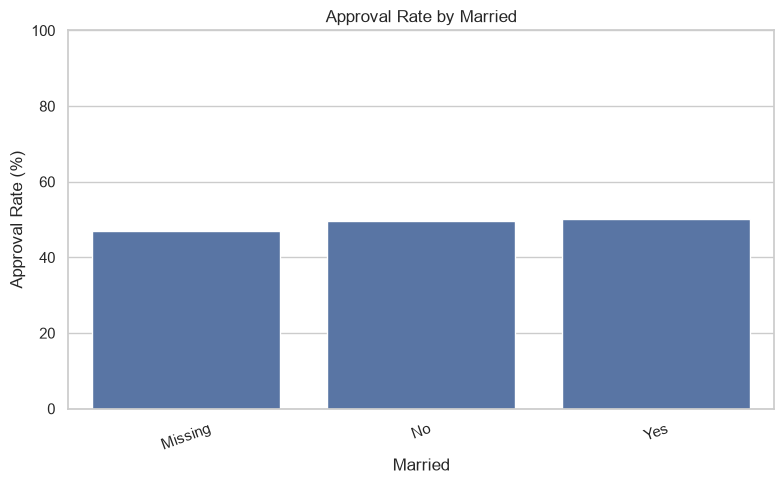

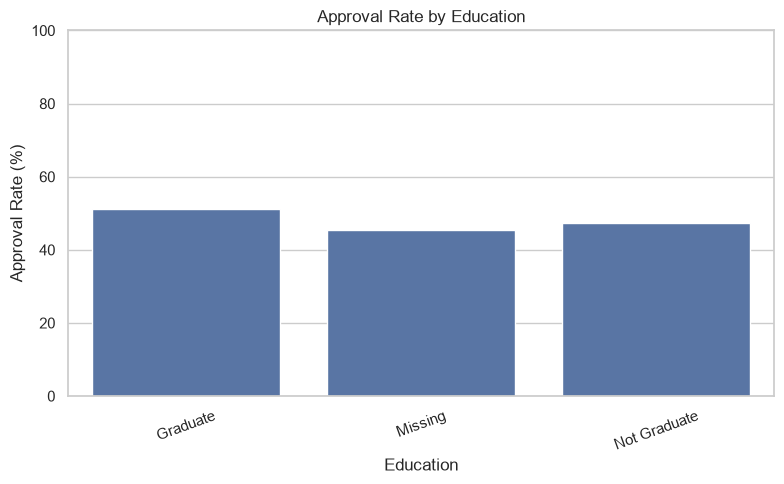

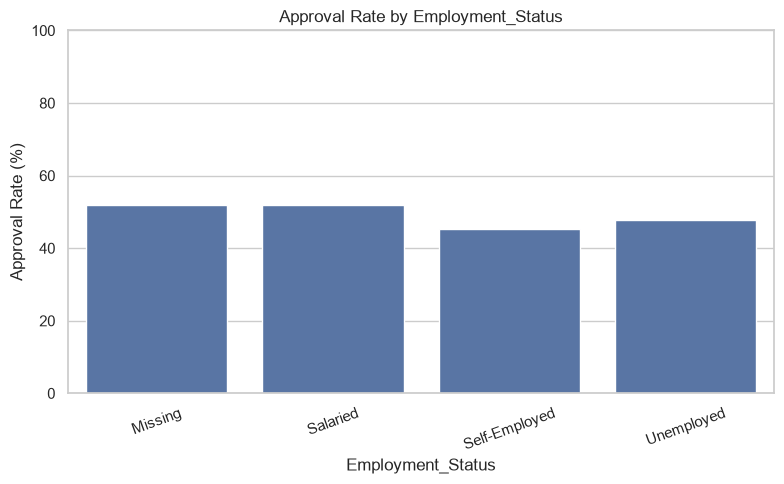

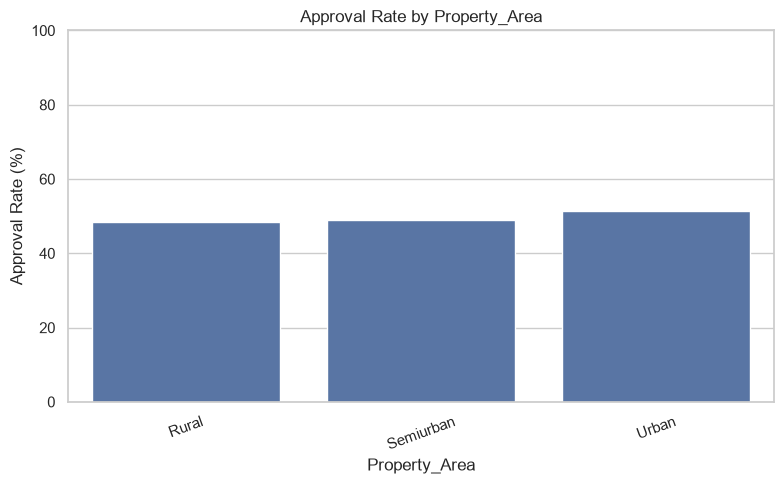

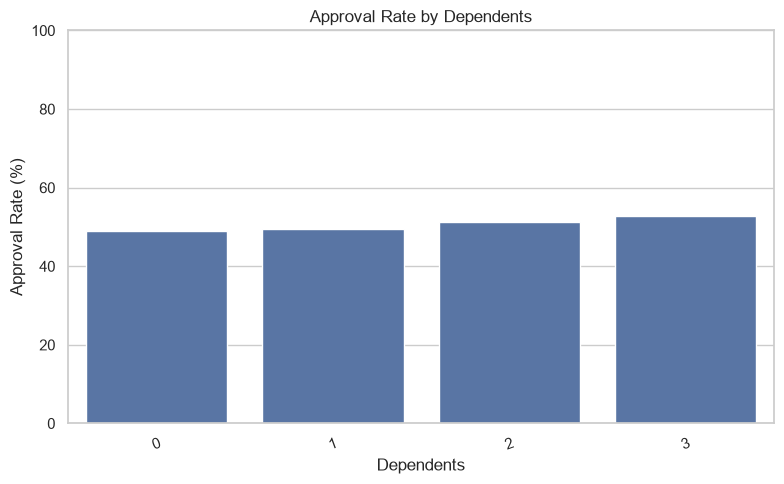

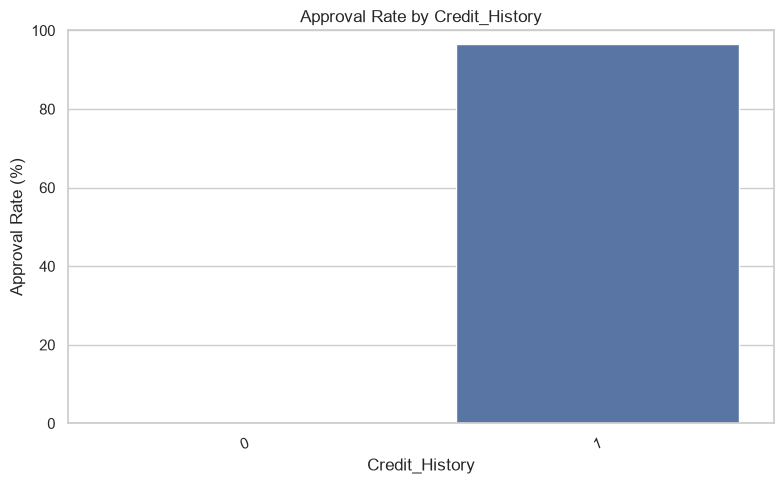

In [40]:
approval_plot_features = [
    "Gender",
    "Married",
    "Education",
    "Employment_Status",
    "Property_Area",
    "Dependents",
    "Credit_History",
]

for feature in approval_plot_features:

    plot_data = df[[feature, "Loan_Status"]].copy()

    plot_data[feature] = plot_data[feature].astype("object").where(
        plot_data[feature].notna(),
        "Missing"
    )

    rate_table = (
        plot_data.groupby(feature)["Loan_Status"]
        .apply(lambda values: (values == "Approved").mean() * 100)
        .reset_index(name="Approval_Rate")
    )

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=rate_table,
        x=feature,
        y="Approval_Rate"
    )

    plt.title(f"Approval Rate by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Approval Rate (%)")
    plt.ylim(0, 100)
    plt.xticks(rotation=20)

    plt.tight_layout()
    plt.show()


## 14. Numerical features vs Loan Status

For numerical variables, we compare the distributions of Approved and Rejected applications.

This helps answer questions such as:

- Do approved applicants have substantially different incomes?
- Are approved loans systematically smaller?
- Is age strongly separated between the two classes?

The important point is to look for **separation between classes**, not just differences in their overall ranges.


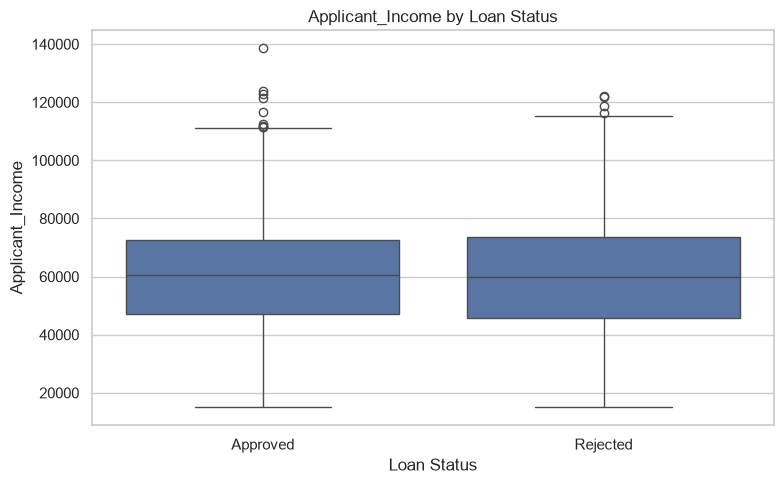

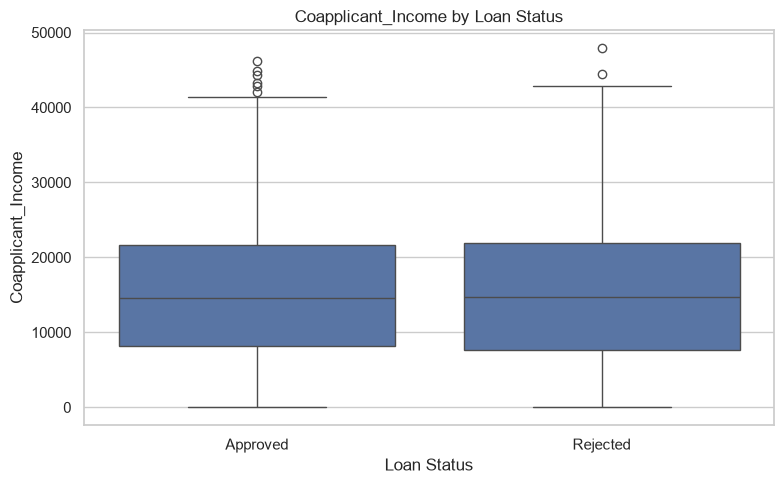

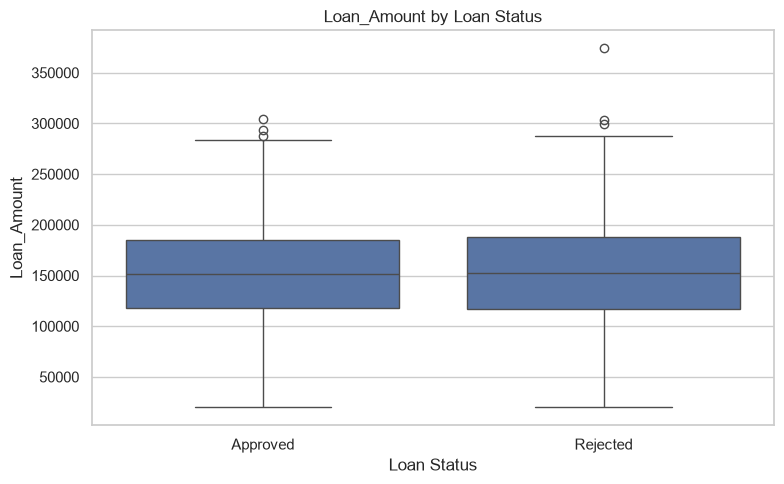

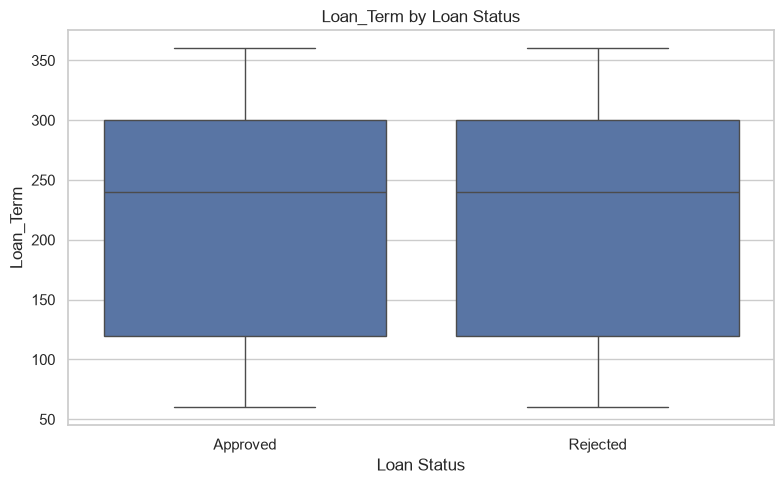

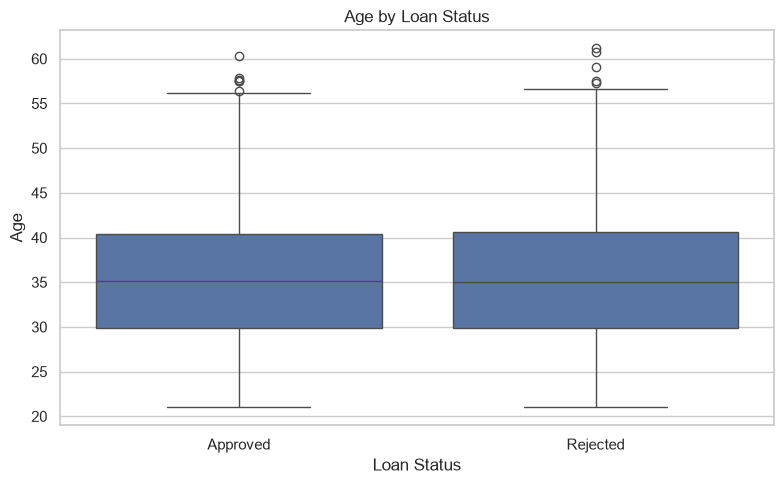

In [34]:
for feature in numerical_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Loan_Status",
        y=feature
    )

    plt.title(f"{feature} by Loan Status")
    plt.xlabel("Loan Status")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()


## 15. Correlation analysis

Correlation measures the strength and direction of a **linear relationship between numerical variables**.

Values are roughly interpreted as:

- `+1` → strong positive relationship
- `0` → little linear relationship
- `-1` → strong negative relationship

Correlation does **not** prove causation.

We include `Credit_History` here because it is encoded numerically, but we interpret its result as a binary-feature association rather than pretending it is a continuous measurement.


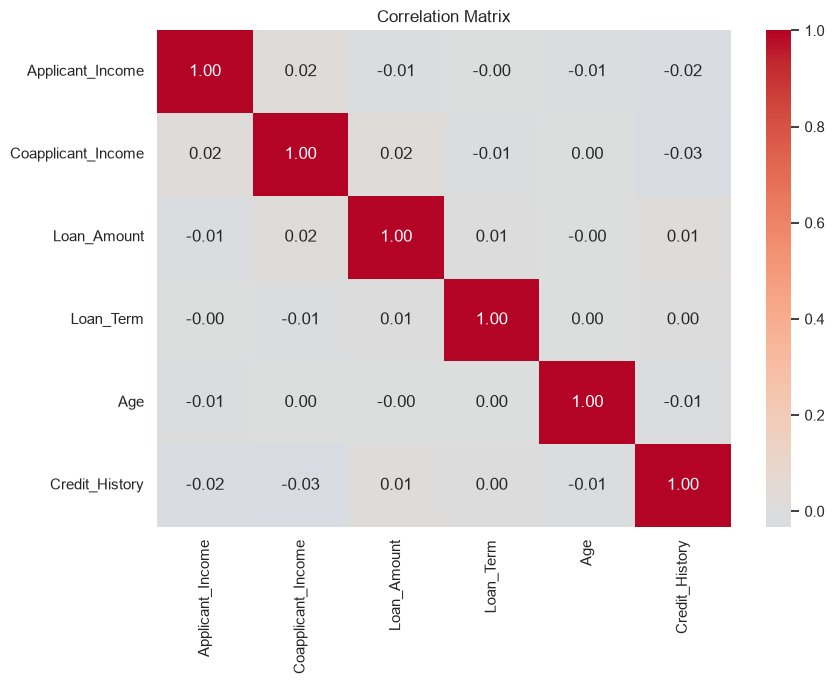

In [35]:
correlation_columns = numerical_features + ["Credit_History"]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 16. Investigating the Credit_History relationship

The earlier analysis suggests that `Credit_History` is unusually predictive of `Loan_Status`.

We now inspect the actual cross-tabulation rather than relying only on a correlation coefficient.

This is an important modelling-risk check because a near-deterministic feature can make a model appear extremely accurate while contributing relatively little evidence about the other features.


In [36]:
credit_status = pd.crosstab(
    df["Credit_History"],
    df["Loan_Status"],
    dropna=False
)

credit_status["Total"] = credit_status.sum(axis=1)

credit_status["Approval_Rate"] = (
    credit_status["Approved"] / credit_status["Total"] * 100
).round(2)

display(credit_status)


Loan_Status,Approved,Rejected,Total,Approval_Rate
Credit_History,,,,
0,1,1541,1542,0.06
1,1595,55,1650,96.67


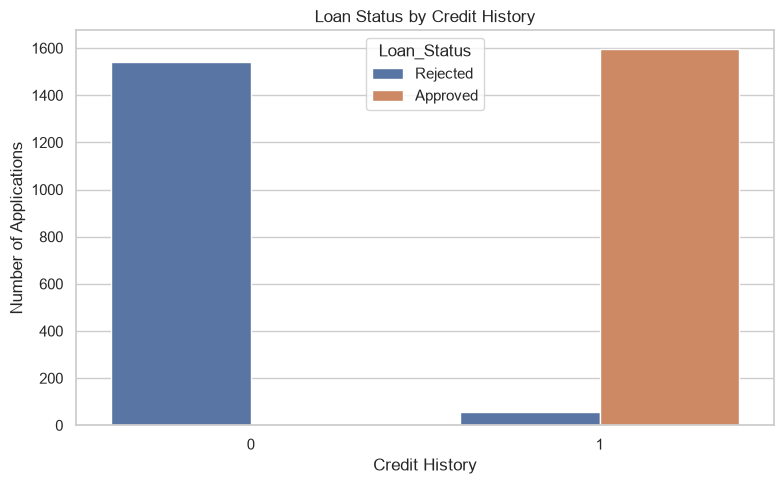

In [37]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Credit_History",
    hue="Loan_Status"
)

plt.title("Loan Status by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Number of Applications")

plt.tight_layout()
plt.show()


### Credit-history warning

If the table shows an almost one-to-one relationship between `Credit_History` and `Loan_Status`, we should **not simply celebrate a very high model accuracy**.

Instead, we should investigate:

1. How much performance comes from `Credit_History`?
2. What happens when it is excluded?
3. Does the model meaningfully use the remaining applicant/financial features?
4. How should our explanation engine communicate this dominance?
5. Should `Credit_History` be treated as non-actionable by the counterfactual engine?

These questions will directly influence LoanLens.


## 17. Feature dominance experiment

This is still EDA rather than final modelling.

We compare the target association of the main features to identify whether one variable dominates the dataset.

For categorical features, we use approval-rate ranges. For numerical features, correlation is only a rough diagnostic and should not be treated as a complete measure of predictive importance.


In [38]:
# Numerical association diagnostic
target_numeric = df["Loan_Status"].map({
    "Rejected": 0,
    "Approved": 1,
})

numeric_association = (
    df[numerical_features + ["Credit_History"]]
    .corrwith(target_numeric)
    .sort_values(key=lambda series: series.abs(), ascending=False)
)

display(numeric_association.to_frame("correlation_with_approval"))


,correlation_with_approval
Credit_History,0.97
Loan_Amount,-0.02
Applicant_Income,0.02
Age,-0.01
Coapplicant_Income,-0.00
Loan_Term,0.00


## 18. Counterfactual feature audit

LoanLens will eventually contain a **What If?** engine.

However, not every feature should be changed by that engine.

We separate features conceptually into:

- **Potentially actionable:** variables such as loan amount, loan term, and income.
- **Non-actionable/immutable:** demographic attributes such as age and gender.
- **Special treatment:** credit history, which may strongly influence the model but cannot responsibly be treated as a simple user-controlled slider.

This is a product-design decision informed by the dataset and the meaning of the variables.


In [39]:
counterfactual_audit = pd.DataFrame({
    "Feature": [
        "Applicant_Income",
        "Coapplicant_Income",
        "Loan_Amount",
        "Loan_Term",
        "Employment_Status",
        "Age",
        "Gender",
        "Married",
        "Dependents",
        "Education",
        "Property_Area",
        "Credit_History",
    ],
    "Counterfactual_Treatment": [
        "Potentially actionable",
        "Potentially actionable",
        "Potentially actionable",
        "Potentially actionable",
        "Potentially actionable, with constraints",
        "Immutable",
        "Immutable",
        "Immutable",
        "Immutable / contextual",
        "Generally non-actionable",
        "Contextual / constrained",
        "Special: non-actionable credit signal",
    ],
})

display(counterfactual_audit)


,Feature,Counterfactual_Treatment
0,Applicant_Income,Potentially actionable
1,Coapplicant_Income,Potentially actionable
2,Loan_Amount,Potentially actionable
3,Loan_Term,Potentially actionable
4,Employment_Status,"Potentially actionable, with constraints"
5,Age,Immutable
6,Gender,Immutable
7,Married,Immutable
8,Dependents,Immutable / contextual
9,Education,Generally non-actionable


## 19. EDA findings

At the end of EDA, we should be able to answer:

### Dataset health
- How many observations are present?
- Are there duplicates?
- How much missing data exists?
- Is the target balanced?

### Feature behaviour
- What are the numerical ranges?
- Which variables are skewed?
- Are there potential outliers?
- Which categorical groups are rare?

### Target relationships
- Which features appear associated with approval?
- Is one feature overwhelmingly dominant?
- Are there possible leakage or synthetic-data concerns?

### LoanLens implications
- Which variables can reasonably participate in counterfactual scenarios?
- Which variables should remain fixed?
- How should explanations communicate dominant features?

The answers here will determine our preprocessing and modelling design.


## 20. EDA checkpoint

**Do not train the final model yet.**

After running this notebook, record the major findings in the project report and use them to justify the next stage:

> **EDA → preprocessing design → baseline models → model comparison → explainability → counterfactual engine → API**

The goal is not merely to achieve the highest accuracy. The goal is to understand what the model is learning and build a decision-analysis system around that understanding.


In [43]:
approval_rate_by("Credit_History")

Loan_Status,Approved,Rejected,Total,Approval_rate_percent
Credit_History,,,,
1,1595,55,1650,96.67
0,1,1541,1542,0.06


In [44]:
approval_rate_by("Employment_Status")

Loan_Status,Approved,Rejected,Total,Approval_rate_percent
Employment_Status,,,,
Salaried,1130,1048,2178,51.88
NaN,29,27,56,51.79
Unemployed,71,78,149,47.65
Self-Employed,366,443,809,45.24


In [45]:
approval_rate_by("Property_Area")

Loan_Status,Approved,Rejected,Total,Approval_rate_percent
Property_Area,,,,
Urban,810,769,1579,51.30
Semiurban,483,504,987,48.94
Rural,303,323,626,48.40


In [46]:
approval_rate_by("Education")

Loan_Status,Approved,Rejected,Total,Approval_rate_percent
Education,,,,
Graduate,1187,1136,2323,51.10
Not Graduate,379,424,803,47.20
NaN,30,36,66,45.45


In [47]:
approval_rate_by("Gender")

Loan_Status,Approved,Rejected,Total,Approval_rate_percent
Gender,,,,
NaN,41,36,77,53.25
Female,564,556,1120,50.36
Male,991,1004,1995,49.67


## Credit History Dominance

The exploratory analysis suggests that Credit_History may dominate the relationship between the input features and Loan_Status.

We therefore compare the target association with and without this feature before designing the final modelling pipeline.

In [48]:
target_numeric = df["Loan_Status"].map({
    "Rejected": 0,
    "Approved": 1
})

numeric_association = (
    df[numerical_features + ["Credit_History"]]
    .corrwith(target_numeric)
    .sort_values(key=lambda series: series.abs(), ascending=False)
)

display(numeric_association.to_frame("correlation_with_approval"))

,correlation_with_approval
Credit_History,0.97
Loan_Amount,-0.02
Applicant_Income,0.02
Age,-0.01
Coapplicant_Income,-0.00
Loan_Term,0.00
